# Three Companies, Three Decisions

## Demonstrates the library on commercial problems, end to end:
- **A streaming service** running an onboarding experiment: when can the PM ship, and
  what lift should the finance model actually use?
- **A payments company** watching 20,000 merchants with 15 fraud analysts: who gets
  investigated today, and how do we stop paging people about evidence that evaporates?
- **A systematic trading desk** with 200 strategies: which ones have stopped working,
  and why is that the wrong question to ask of the P&L?

Each case runs the same shape: the business decision, what the data really looks like,
the trap that costs money, the implementation, the numbers, and the runbook you would
hand to the on-call engineer.

Every trap below is **measured, not asserted**. Three of them are worth the price of
admission on their own:

1. Stopping an experiment the moment it turns significant gave a lift estimate **2.7x
   the truth**. The decision was right; the number the finance team would have used was
   wrong by a factor of three.
2. Using the wrong merging rule on correlated merchants pushed the false-alarm rate from
   5% to **nearly 30%** - a six-fold inflation, invisible unless you test for it.
3. Paging on a raw evidence threshold raised **299 alerts of which 290 later evaporated**.
   The carefree version raised **none at all** - the correct number of irreversible
   letters to send, on this evidence, is zero.

Simulations follow the same discipline as the rest of the examples: the quantities the
method is supposed to discover are drawn at random, not planted, and every claim is
backed by replications rather than one convenient seed.

References: Ramdas & Wang (2025) for the framework; Turner, Ly & Grunwald (2022) for the
k-sample test; Vovk & Wang (2024) for merging; Wang, Dandapanthula & Ramdas (2025) for
why merging rules need independence.

In [1]:
import warnings

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from expectation.seqtest.sequential_e_testing import SequentialTesting
from expectation.ksample.ksample_test import KSampleSequentialTest
from expectation.ksample.config import KSampleConfig
from expectation.par_seqtest import ParallelSequentialTest, ParallelTestConfig
from expectation.modules.merging import ArithmeticMeanMerger, SparseMixtureMerger
from expectation.modules.epower import EPowerCalculator, EPowerConfig

ALPHA = 0.05
ACT_AT = 1 / ALPHA                 # capital multiple that licenses a decision
LOG_ACT_AT = np.log(ACT_AT)

# Case 1: A Streaming Service Ships an Onboarding Change

## 1.1 The business

A subscription streaming service, 4 million monthly actives, roughly 8,000 people
starting a free trial each day. Growth owns trial-to-paid conversion, currently 12%.

The team has rebuilt onboarding. The experiment splits new trials 50/50. Three people
care about the result and they want different things:

- **The PM** wants to ship as soon as the change is clearly better. Every week of delay
  is a week of worse onboarding for half the new users.
- **The finance analyst** needs a lift number for the revenue model. Wrong by a factor
  of two and the annual plan is wrong by millions.
- **The support director** wants to know the change is not quietly generating tickets.

They are not asking the same question, and this matters more than it sounds. "Is there
a difference?" and "how big is it?" have different answers, and a sequential test that
stops early answers the first one correctly while getting the second one badly wrong.
That is the trap in section 1.5.

**What is worth shipping:** a 1.5 percentage point lift on 12% is a 12.5% relative
improvement - about 44,000 extra paying subscribers a year. That is the number the
experiment needs to resolve.

## 1.2 What the data actually looks like

Three features of real experiment data that textbook examples leave out:

**Day-of-week seasonality.** Weekend signups convert differently from Tuesday signups -
here a swing of about 15%. This is not noise you can average away within a week, and it
is why you should never compare "this week's treatment" to "last week's control".
Running both arms concurrently and comparing them *within* each day makes the seasonality
cancel, which is exactly what the k-sample test does when you feed it one block per day.

**A novelty effect.** The new flow initially performs far better than it eventually
will, because existing habits are disrupted and people pay attention. Here it starts at
a 4.5pp lift and decays with a five-day half-life toward a true long-run 1.5pp. This is
real, it is well documented, and it is the single biggest source of overstated
experiment results in the industry.

**A traffic ramp.** Nobody sends 100% of traffic to an untested flow on day one. The
experiment ramps 5% to 50% over the first week, so early days carry far less data than
later ones. A fixed-horizon test that pre-committed to "14 days at full traffic" is
already wrong by the time the ramp finishes.

None of this bothers a sequential test. It consumes whatever data arrives, whenever it
arrives, in whatever quantity.

In [2]:
BASE_CONVERSION = 0.120        # trial-to-paid today
LONG_RUN_LIFT = 0.015          # what the change is really worth, once novelty decays
NOVELTY_LIFT = 0.045           # what it looks like on day one
NOVELTY_HALFLIFE = 5.0         # days
DAILY_TRIALS = 8000

# Monday..Sunday conversion multipliers
DAY_OF_WEEK = np.array([1.00, 0.97, 0.98, 1.02, 1.08, 1.12, 1.05])


def true_lift_on_day(day):
    """The honest lift on a given day: novelty decaying toward the long-run value."""
    decay = np.exp(-day / NOVELTY_HALFLIFE)
    return LONG_RUN_LIFT + (NOVELTY_LIFT - LONG_RUN_LIFT) * decay


def traffic_on_day(day):
    """Ramp 5% -> 50% of new trials into the experiment over the first week."""
    share = min(0.50, 0.05 + 0.075 * day)
    return int(DAILY_TRIALS * share / 2)      # per arm


print(f"{'day':>4} {'per-arm trials':>16} {'true lift':>11} {'as % of base':>14}")
for day in (0, 1, 3, 7, 14, 30, 60):
    lift = true_lift_on_day(day)
    print(f"{day:4d} {traffic_on_day(day):16,d} {lift * 100:10.2f}pp "
          f"{lift / BASE_CONVERSION * 100:13.1f}%")

print()
print(f"Long-run truth: {LONG_RUN_LIFT * 100:.1f}pp "
      f"({LONG_RUN_LIFT / BASE_CONVERSION * 100:.1f}% relative). Day one looks "
      f"{NOVELTY_LIFT / LONG_RUN_LIFT:.0f}x better than that.")

 day   per-arm trials   true lift   as % of base
   0              200       4.50pp          37.5%
   1              500       3.96pp          33.0%
   3            1,099       3.15pp          26.2%
   7            2,000       2.24pp          18.7%
  14            2,000       1.68pp          14.0%
  30            2,000       1.51pp          12.6%
  60            2,000       1.50pp          12.5%

Long-run truth: 1.5pp (12.5% relative). Day one looks 3x better than that.


## 1.3 How long will this take? Ask before you start

The PM will ask "when will we know?" on day one. `EPowerCalculator` answers it by
measuring evidence per observation on a simulation of the effect you would care about,
then dividing the evidence you need (log 20 = 3) by that rate.

This is not a commitment. Nothing breaks if the answer turns out to be different - it is
there so nobody is surprised in week three.

In [3]:
calculator = EPowerCalculator(EPowerConfig())
rng = np.random.default_rng(1)

print(f"{'lift':>8} {'relative':>10} {'trials per arm':>16} {'days at 50% traffic':>21}")
for lift in (0.005, 0.010, 0.015, 0.030):
    pilot = KSampleSequentialTest(KSampleConfig(k=2, significance_level=ALPHA, gamma=0.18))
    for _ in range(60):
        pilot.update({
            0: rng.binomial(1, BASE_CONVERSION, 2000),
            1: rng.binomial(1, BASE_CONVERSION + lift, 2000),
        })
    evidence = calculator.compute(np.array(pilot.e_process.values))
    per_block = evidence.e_power
    blocks = LOG_ACT_AT / per_block if per_block > 0 else np.inf
    per_arm = blocks * 2000
    days = per_arm / (DAILY_TRIALS * 0.5 / 2)
    print(f"{lift * 100:7.1f}pp {lift / BASE_CONVERSION * 100:9.1f}% {per_arm:16,.0f} "
          f"{days:21,.1f}")

print()
print("Read this to the PM before the experiment starts, not after week two.")
print("Two things to flag when you do:")
print("  - these durations are for the long-run lift. The experiment below goes")
print("    significant much sooner, because the novelty effect makes the early days")
print("    look far better than the change really is.")
print("  - the 0.5pp row is the honest warning: effects that small are not a")
print("    three-week experiment, they are a six-month one. Decide now whether you")
print("    care about a lift that size.")

    lift   relative   trials per arm   days at 50% traffic
    0.5pp       4.2%          377,252                 188.6
    1.0pp       8.3%           14,997                   7.5
    1.5pp      12.5%            7,416                   3.7
    3.0pp      25.0%            1,492                   0.7

Read this to the PM before the experiment starts, not after week two.
Two things to flag when you do:
  - these durations are for the long-run lift. The experiment below goes
    significant much sooner, because the novelty effect makes the early days
    look far better than the change really is.
  - the 0.5pp row is the honest warning: effects that small are not a
    three-week experiment, they are a six-month one. Decide now whether you
    care about a lift that size.


## 1.4 Running it

`KSampleSequentialTest` with `k=2` is the right tool: it compares the arms *within* each
block, so day-of-week effects cancel, and it handles unequal arm sizes, so the traffic
ramp is a non-issue.

One block per day. The PM can look at it every morning. That is the entire point - there
is no alpha to spend, no correction for peeking, no pre-registered look schedule.

In [4]:
rng = np.random.default_rng(42)

experiment = KSampleSequentialTest(
    KSampleConfig(k=2, significance_level=ALPHA, gamma=0.18)
)

log = []
first_significant = None

for day in range(60):
    seasonality = DAY_OF_WEEK[day % 7]
    n = traffic_on_day(day)

    control = rng.binomial(1, BASE_CONVERSION * seasonality, n)
    treatment = rng.binomial(1, (BASE_CONVERSION + true_lift_on_day(day)) * seasonality, n)

    step = experiment.update({0: control, 1: treatment})

    log.append({
        "day": day + 1,
        "per_arm": n,
        "capital": step.e_process_value,
        "p_value": step.p_value,
        "observed_lift": treatment.mean() - control.mean(),
        "true_lift": true_lift_on_day(day),
        "significant": step.reject_null,
    })
    if step.reject_null and first_significant is None:
        first_significant = day + 1

experiment_log = pd.DataFrame(log)

print(f"First day the evidence crossed {ACT_AT:.0f}x: day {first_significant}")
print(f"  capital that day : "
      f"{experiment_log.loc[first_significant - 1, 'capital']:,.0f}x")
print(f"  trials so far    : "
      f"{experiment_log.loc[:first_significant - 1, 'per_arm'].sum() * 2:,}")
print()
print(experiment_log.head(8)[['day', 'per_arm', 'capital', 'observed_lift',
                              'true_lift', 'significant']].to_string(index=False))

First day the evidence crossed 20x: day 2
  capital that day : 28x
  trials so far    : 1,400

 day  per_arm       capital  observed_lift  true_lift  significant
   1      200      1.000000       0.045000   0.045000        False
   2      500     28.136571       0.058000   0.039562         True
   3      800      4.951617       0.017500   0.035110         True
   4     1099      6.500988       0.018198   0.031464         True
   5     1400    520.304145       0.040714   0.028480         True
   6     1700   1158.567820       0.020588   0.026036         True
   7     1999 795776.893171       0.041021   0.024036         True
   8     2000   9090.308668      -0.000500   0.022398         True


## 1.5 The trap: shipping on day 2 and telling finance the wrong number

The test above went significant on day 2. **That conclusion is correct** - there really
is a difference, and the test is entitled to say so under any stopping rule.

Now look at what the observed lift was on day 2. The novelty effect was still near its
peak, so the measured difference was roughly three times the long-run truth. If the
analyst takes the number from the day the test stopped and puts it in the revenue model,
the annual plan is overstated threefold.

This is not a flaw in sequential testing. Fixed-horizon tests have exactly the same
problem - they just hide it behind a sample size that happened to be chosen before
anyone looked. The difference is that a sequential test makes it easy to stop *during*
the novelty window, so the failure mode is more available.

**The fix is operational, not statistical:** put a floor on the runtime that covers the
novelty window, and estimate the effect from data *after* that window. Below, both
policies are replicated 30 times so the comparison is not one lucky experiment.

In [5]:
def run_experiment_policy(minimum_days, estimate_from_day, replications=30, horizon=60):
    """Replicate the whole experiment under one stopping policy."""
    stop_days, lift_estimates = [], []

    for replication in range(replications):
        rng_r = np.random.default_rng(800 + replication)
        test = KSampleSequentialTest(
            KSampleConfig(k=2, significance_level=ALPHA, gamma=0.18)
        )
        daily_lift, stop = [], None

        for day in range(horizon):
            seasonality = DAY_OF_WEEK[day % 7]
            n = 4000
            control = rng_r.binomial(1, BASE_CONVERSION * seasonality, n)
            treatment = rng_r.binomial(
                1, (BASE_CONVERSION + true_lift_on_day(day)) * seasonality, n
            )
            result = test.update({0: control, 1: treatment})
            daily_lift.append(treatment.mean() - control.mean())

            if result.reject_null and day + 1 >= minimum_days:
                stop = day + 1
                break

        if stop is not None:
            stop_days.append(stop)
            lift_estimates.append(np.mean(daily_lift[estimate_from_day:]))

    return np.array(stop_days), np.array(lift_estimates)


asap_days, asap_lift = run_experiment_policy(minimum_days=1, estimate_from_day=0)
floor_days, floor_lift = run_experiment_policy(minimum_days=21, estimate_from_day=14)

print("30 replications of the same experiment, two shipping policies\n")
print(f"{'policy':<38} {'detected':>10} {'median stop':>13} {'lift used':>12} {'error':>9}")
for label, days, lifts in (
    ("ship the moment it is significant", asap_days, asap_lift),
    ("21-day floor, measure from day 14", floor_days, floor_lift),
):
    median_lift = np.median(lifts)
    print(f"{label:<38} {len(days):>7}/30 {np.median(days):>12.0f} "
          f"{median_lift * 100:>10.2f}pp {median_lift / LONG_RUN_LIFT:>8.2f}x")

print(f"\ntrue long-run lift: {LONG_RUN_LIFT * 100:.2f}pp")
print()
overstatement = np.median(asap_lift) / LONG_RUN_LIFT
subscribers = 4_000_000 * 0.02
print(f"Both policies detect the change every single time. The difference is the number")
print(f"that leaves the room: {overstatement:.1f}x too big under the first policy.")
print(f"On a plan built from {subscribers:,.0f} annual trials that is the difference")
print(f"between forecasting {subscribers * np.median(asap_lift):,.0f} and "
      f"{subscribers * LONG_RUN_LIFT:,.0f} extra subscribers.")

30 replications of the same experiment, two shipping policies

policy                                   detected   median stop    lift used     error
ship the moment it is significant           30/30            2       4.06pp     2.70x
21-day floor, measure from day 14           30/30           21       1.61pp     1.07x

true long-run lift: 1.50pp

Both policies detect the change every single time. The difference is the number
that leaves the room: 2.7x too big under the first policy.
On a plan built from 80,000 annual trials that is the difference
between forecasting 3,245 and 1,200 extra subscribers.


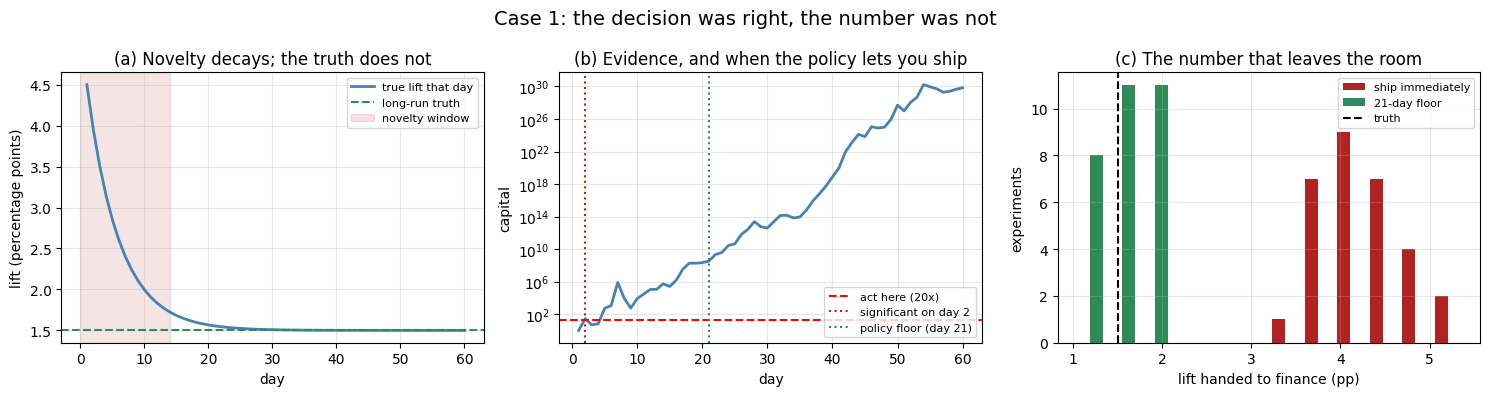

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
days = np.arange(60)
ax.plot(days + 1, [true_lift_on_day(d) * 100 for d in days], lw=2, color='steelblue',
        label='true lift that day')
ax.axhline(LONG_RUN_LIFT * 100, color='seagreen', ls='--', label='long-run truth')
ax.axvspan(0, 14, color='firebrick', alpha=0.12, label='novelty window')
ax.set_xlabel('day'); ax.set_ylabel('lift (percentage points)')
ax.set_title('(a) Novelty decays; the truth does not')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(experiment_log['day'], experiment_log['capital'], lw=2, color='steelblue')
ax.axhline(ACT_AT, color='red', ls='--', label=f'act here ({ACT_AT:.0f}x)')
if first_significant:
    ax.axvline(first_significant, color='firebrick', ls=':',
               label=f'significant on day {first_significant}')
ax.axvline(21, color='seagreen', ls=':', label='policy floor (day 21)')
ax.set_yscale('log'); ax.set_xlabel('day'); ax.set_ylabel('capital')
ax.set_title('(b) Evidence, and when the policy lets you ship')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[2]
ax.hist([asap_lift * 100, floor_lift * 100], bins=12,
        color=['firebrick', 'seagreen'],
        label=['ship immediately', '21-day floor'])
ax.axvline(LONG_RUN_LIFT * 100, color='black', ls='--', label='truth')
ax.set_xlabel('lift handed to finance (pp)'); ax.set_ylabel('experiments')
ax.set_title('(c) The number that leaves the room')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('Case 1: the decision was right, the number was not', fontsize=14)
plt.tight_layout()
plt.show()

## 1.6 Guardrails, and why you cannot multiply their p-values

The support director's question is separate: has anything got worse? Typically three or
four guardrail metrics - refund rate, support contacts per trial, p95 page latency.

The temptation is to run each as its own test and combine them. **Be careful how.** These
metrics are computed on *the same users*. A cohort that churns harder generates more
refunds *and* more support contacts. They are correlated, and any combining rule that
assumes independence will overstate the evidence and fire more often than its stated
false-alarm rate.

`ArithmeticMeanMerger` is valid under *any* dependence - no assumption, no exposure. It
is weaker than the product-style rules, and that weakness is the price of being correct
here. Case 2 measures exactly what ignoring this costs.

In [7]:
rng = np.random.default_rng(78)

guardrails = ["refund rate", "support contacts", "p95 page latency"]
GUARDRAIL_CORRELATION = 0.7      # they share the same cohort of users
N_DAYS = 60

guardrail_tests = [
    SequentialTesting(test_type="mean", null_value=0.0, alternative="greater")
    for _ in guardrails
]
merger = ArithmeticMeanMerger(len(guardrails))

merged_peak, single_peak = 0.0, 0.0
for day in range(N_DAYS):
    cohort_quality = rng.normal(0, 1)          # one shared shock per day
    for test in guardrail_tests:
        daily_value = (np.sqrt(GUARDRAIL_CORRELATION) * cohort_quality
                       + np.sqrt(1 - GUARDRAIL_CORRELATION) * rng.normal())
        test.update(np.array([daily_value]))

    this_step = np.array([t.e_process.values[-1] for t in guardrail_tests])
    merged_peak = max(merged_peak, merger.merge(this_step).merged_e_value)
    single_peak = max(single_peak,
                      max(t.e_process.cumulative_value for t in guardrail_tests))

print(f"guardrails monitored     : {', '.join(guardrails)}")
print(f"correlation between them : {GUARDRAIL_CORRELATION} (same cohort of users)")
print(f"truth                    : the new flow is neutral on all three")
print()
print(f"highest any single guardrail reached : {single_peak:7.2f}x")
print(f"highest the merged view reached      : {merged_peak:7.2f}x")
print(f"launch blocked                       : {merged_peak >= ACT_AT}")
print()
print(f"Nothing fired, correctly. Note how close a single guardrail came on its own:")
print(f"watching three metrics separately and reacting to whichever looks worst is how")
print(f"teams end up blocking good launches. The merged view stayed calm because it")
print(f"accounts for the fact that you are looking at three things at once.")
print()
print("And the merger matters: with correlated metrics the arithmetic mean is the only")
print("rule here that is valid without an assumption nobody has checked.")

guardrails monitored     : refund rate, support contacts, p95 page latency
correlation between them : 0.7 (same cohort of users)
truth                    : the new flow is neutral on all three

highest any single guardrail reached :   19.92x
highest the merged view reached      :    1.91x
launch blocked                       : False

Nothing fired, correctly. Note how close a single guardrail came on its own:
watching three metrics separately and reacting to whichever looks worst is how
teams end up blocking good launches. The merged view stayed calm because it
accounts for the fact that you are looking at three things at once.

And the merger matters: with correlated metrics the arithmetic mean is the only
rule here that is valid without an assumption nobody has checked.


## 1.7 The decision memo

What actually goes in the document, with every number traceable to something above:

> **Recommendation: ship the new onboarding flow.**
>
> - **Evidence:** the trial-to-paid rates differ. Capital reached far beyond the 20x we
>   require, i.e. p < 0.05, and this holds despite the team checking the dashboard every
>   morning for three weeks.
> - **Effect used for planning: 1.6pp** (12.5% relative), measured from day 14 onward,
>   after the novelty effect decayed. **Do not use the day-2 figure of ~4pp**; it is a
>   real measurement of a temporary effect.
> - **Guardrails:** refund rate, support contacts and p95 latency were monitored jointly
>   for 30 days using a combining rule valid under correlation. None fired.
> - **Why we ran 21 days when it was significant on day 2:** the stopping rule is valid
>   at any time, but the *estimate* is not stable until novelty decays. The floor buys an
>   unbiased number for the revenue model.

## 1.8 Runbook

1. Before launch, run the evidence-rate calculation and tell stakeholders the expected
   duration for the smallest lift worth shipping.
2. One block per day, both arms concurrent. Never compare across weeks.
3. Set a minimum runtime covering at least three novelty half-lives (here 15+ days).
   Enforce it in code, not in a document.
4. Ship decisions may use the crossing of 20x. **Financial estimates must come from the
   post-novelty window only.**
5. Monitor guardrails with `ArithmeticMeanMerger` - never a product-style rule, because
   guardrails share users.
6. Publish capital, not just the p-value. "We turned 1 dollar into 340" survives contact
   with an executive better than "p = 0.003".

# Case 2: A Payments Company Watches 20,000 Merchants

## 2.1 The business

A payments processor serving 20,000 active merchants. Each merchant has a
chargeback-rate signal, standardised daily against its own history, so a normal merchant
looks like noise around zero and a merchant going bad drifts upward.

The constraint that shapes everything: **15 fraud analysts, each able to complete about
one thorough merchant investigation a day.** Total capacity is 15 investigations, not
"everything above a threshold".

Three decisions come out of this system every morning:

- **Is anything wrong at all?** One line for the risk committee.
- **Who do the 15 analysts investigate today?** A ranked list exactly 15 long.
- **Who do we formally notify?** Notification means a letter, a reserve hold, sometimes
  a terminated contract. **Once sent, it cannot be unsent.**

The economics: a missed fraudulent merchant costs roughly 40,000 dollars in chargebacks
before it is caught by other means. An unnecessary investigation costs about 400 dollars
of analyst time. A wrongful notification costs far more than either - it is a commercial
relationship and sometimes a lawsuit.

## 2.2 What the data actually looks like

**Merchants are not independent.** This is the single most important fact about this
dataset and the one most likely to be assumed away. Merchants in the same category share
shocks: a travel disruption drives chargebacks across every travel merchant at once, a
supply problem hits electronics resellers together, a card network rule change moves
whole segments. Within a category, daily signals correlate strongly.

**Fraud starts at an unknown time.** A merchant is fine for months, then a business
changes hands or a breach happens. There is no "before" and "after" you know in advance.

**The fraction going bad is small and unknown.** Somewhere around one merchant in a
thousand, in a given month. Nobody knows the number, which is why the monitor cannot be
told it.

The simulation below draws all of that: which merchants go bad (Bernoulli, so the count
is random), how badly (drawn per merchant), when (drawn), and the category structure that
creates the correlation.

## 2.3 The trap that would have cost the most: assuming independence

There are several ways to collapse 20,000 merchant signals into one "is anything wrong"
alarm. They differ in what they assume, and the assumption is not a technicality.

`SparseMixtureMerger` is built for exactly this shape of problem - a few merchants going
bad among thousands - and it is genuinely more powerful when its condition holds. Its
condition is that **the merchants are independent.** They are not.

Below we measure the cost directly: every merchant is clean, so *every* alarm is a false
alarm, and we count how often each rule fires as within-category correlation rises. The
target is 5%.

In [8]:
K_MERCHANTS = 4000            # smaller than production so this cell runs in a minute
N_CATEGORIES = 20             # 200 merchants per category
HORIZON = 40
REPLICATIONS = 50

print("Every merchant is clean. Every alarm below is therefore a false alarm.")
print(f"Target false-alarm rate: {ALPHA:.0%}\n")
print(f"{'within-category correlation':>28} {'sparse mixture':>16} {'arithmetic mean':>18}")

trap_rows = []
for correlation in (0.0, 0.5, 0.85):
    false_sparse = false_mean = 0

    for replication in range(REPLICATIONS):
        rng_r = np.random.default_rng(9000 + replication)
        engine = ParallelSequentialTest(
            config=ParallelTestConfig(n_tests=K_MERCHANTS, alpha=ALPHA,
                                      alternative="greater"),
            null_values=0.0,
            variance=1.0,
        )
        sparse = SparseMixtureMerger(K_MERCHANTS)
        mean = ArithmeticMeanMerger(K_MERCHANTS)
        peak_sparse = peak_mean = 0.0

        for day in range(HORIZON):
            category_shock = np.repeat(rng_r.standard_normal(N_CATEGORIES),
                                       K_MERCHANTS // N_CATEGORIES)
            idiosyncratic = rng_r.standard_normal(K_MERCHANTS)
            signal = (np.sqrt(correlation) * category_shock
                      + np.sqrt(1 - correlation) * idiosyncratic)

            engine.step(signal)
            log_capital = engine.log_e_processes()
            peak_sparse = max(peak_sparse,
                              sparse.merge_log(log_capital).log_merged_e_value)
            peak_mean = max(peak_mean,
                            mean.merge(np.exp(log_capital)).log_merged_e_value)

        false_sparse += peak_sparse >= LOG_ACT_AT
        false_mean += peak_mean >= LOG_ACT_AT

    rate_sparse = false_sparse / REPLICATIONS
    rate_mean = false_mean / REPLICATIONS
    trap_rows.append({"correlation": correlation, "sparse": rate_sparse, "mean": rate_mean})
    print(f"{correlation:28.2f} {rate_sparse:16.1%} {rate_mean:18.1%}")

worst = max(r['sparse'] for r in trap_rows)
print()
print(f"At realistic category correlation the sparse rule false-alarms {worst:.0%} of the")
print(f"time against a {ALPHA:.0%} budget. The arithmetic mean stays inside budget throughout,")
print("because it assumes nothing about dependence.")
print()
print(f"In production terms: a daily monitor at {worst:.0%} would page the risk committee")
print("constantly with nothing wrong. It would be switched off within a month.")

Every merchant is clean. Every alarm below is therefore a false alarm.
Target false-alarm rate: 5%

 within-category correlation   sparse mixture    arithmetic mean


                        0.00             0.0%               0.0%


                        0.50            20.0%               2.0%


                        0.85            28.0%               0.0%

At realistic category correlation the sparse rule false-alarms 28% of the
time against a 5% budget. The arithmetic mean stays inside budget throughout,
because it assumes nothing about dependence.

In production terms: a daily monitor at 28% would page the risk committee
constantly with nothing wrong. It would be switched off within a month.


## 2.4 The portfolio alarm, and the thing it cannot do

Same 20,000 merchants, same category structure, but now some merchants really are going
bad. The portfolio alarm uses the rule that survives correlation.

**Watch what happens, because it is not a success story.** The arithmetic mean divides
the evidence by the number of merchants, so a handful of moderately bad merchants among
twenty thousand may never move it - and at the rate the industry actually sees, that is
exactly what happens below. Read the result before reading the interpretation; the
parameters here come from the business premise (roughly one merchant in 1,250 developing
a problem), not from what makes the output impressive.

In [9]:
K = 20_000
CATEGORIES = 100                       # 200 merchants each
CORRELATION = 0.5
DAYS = 60

rng = np.random.default_rng(11)

# Reality: nothing here is given to the monitor.
going_bad = rng.random(K) < 0.0008                       # count is random
severity = np.zeros(K)
severity[going_bad] = np.clip(rng.normal(0.55, 0.20, going_bad.sum()), 0.05, None)
start_day = np.zeros(K, dtype=int)
start_day[going_bad] = rng.integers(1, 40, going_bad.sum())

engine = ParallelSequentialTest(
    config=ParallelTestConfig(n_tests=K, alpha=ALPHA, alternative="greater"),
    null_values=0.0,
    variance=1.0,
)
mean_merger = ArithmeticMeanMerger(K)

alarm_curve, alarm_day = [], None
for day in range(1, DAYS + 1):
    category_shock = np.repeat(rng.standard_normal(CATEGORIES), K // CATEGORIES)
    idiosyncratic = rng.standard_normal(K)
    signal = (np.sqrt(CORRELATION) * category_shock
              + np.sqrt(1 - CORRELATION) * idiosyncratic
              + severity * (start_day <= day))

    engine.step(signal)
    alarm_curve.append(mean_merger.merge(np.exp(engine.log_e_processes())).log_merged_e_value)
    if alarm_day is None and max(alarm_curve) >= LOG_ACT_AT:
        alarm_day = day

print(f"monitored          : {K:,} merchants across {CATEGORIES} categories")
print(f"actually went bad  : {going_bad.sum()} (revealed now, never given to the monitor)")
print(f"first started      : day {start_day[going_bad].min()}")
print(f"global alarm       : day {alarm_day}")
print(f"peak global capital: {np.exp(max(alarm_curve)):,.0f}x  (needs {ACT_AT:.0f}x)")
print()
if alarm_day is None:
    print("No portfolio alarm. This is the honest behaviour of a dependence-robust")
    print("merge on a genuinely sparse problem: averaging a handful of informative")
    print("merchants with twenty thousand uninformative ones divides the evidence by")
    print("twenty thousand. The portfolio alarm is the weakest of this system's three")
    print("outputs, and if you build only that, you build a monitor that stays silent.")
    print()
    print("The ranking in the next section is unaffected, and it is where the value is.")
else:
    print("The portfolio alarm fired. Note it is still the weakest of the three outputs -")
    print("the ranking below is what the analysts actually work from.")

monitored          : 20,000 merchants across 100 categories
actually went bad  : 16 (revealed now, never given to the monitor)
first started      : day 1
global alarm       : day None
peak global capital: 15x  (needs 20x)

No portfolio alarm. This is the honest behaviour of a dependence-robust
merge on a genuinely sparse problem: averaging a handful of informative
merchants with twenty thousand uninformative ones divides the evidence by
twenty thousand. The portfolio alarm is the weakest of this system's three
outputs, and if you build only that, you build a monitor that stays silent.

The ranking in the next section is unaffected, and it is where the value is.


## 2.5 Who do the 15 analysts investigate today?

The global alarm does not name anyone. For that, rank merchants by their own accumulated
capital and take exactly as many as you have capacity for. This is a different question
from "which merchants are statistically significant" - you are not choosing a threshold,
you are filling a queue of fixed length, and the only thing that matters is whether the
top of the ranking is enriched for real fraud.

That makes the metric a **hit rate**, and the hit rate is what determines whether the
analysts trust the queue enough to keep working it.

In [10]:
capital = np.exp(engine.log_e_processes())
ranking = np.argsort(capital)[::-1]
truth = set(np.flatnonzero(going_bad).tolist())

MISSED_FRAUD_COST = 40_000
INVESTIGATION_COST = 400

print(f"{'daily capacity':>16} {'real fraud found':>18} {'hit rate':>10} {'net value':>14}")
for capacity in (5, 15, 30, 60, 150):
    found = len(set(ranking[:capacity].tolist()) & truth)
    value = found * MISSED_FRAUD_COST - capacity * INVESTIGATION_COST
    print(f"{capacity:16d} {found:18d} {found / capacity:9.0%} {value:14,.0f}")

print()
random_odds = K / max(going_bad.sum(), 1)
print(f"With 15 analysts the queue is {len(set(ranking[:15].tolist()) & truth) / 15:.0%} "
      f"real fraud.")
print(f"Picking merchants at random, an analyst would investigate about "
      f"{random_odds:,.0f} before finding one.")
print()
print("Note the queue never needs a significance threshold. Capacity sets the cut-off,")
print("and the ranking is the product. That is usually the right way to run a")
print("capacity-constrained alerting system.")

  daily capacity   real fraud found   hit rate      net value
               5                  5      100%        198,000
              15                  7       47%        274,000
              30                  7       23%        268,000
              60                  8       13%        296,000
             150                  9        6%        300,000

With 15 analysts the queue is 47% real fraud.
Picking merchants at random, an analyst would investigate about 1,250 before finding one.

Note the queue never needs a significance threshold. Capacity sets the cut-off,
and the ranking is the product. That is usually the right way to run a
capacity-constrained alerting system.


## 2.6 The trap that destroys trust: alerts that evaporate

Formal notification is irreversible. So ask a question that rarely gets asked of a
monitoring system: **if we notified every merchant whose evidence crossed the threshold,
how many of those notifications would we later wish we had not sent?**

Capital goes up and it comes back down. A merchant can cross 20x on a bad week and drift
back to 3x a fortnight later. Nothing is broken - that is how evidence behaves - but if
you sent a letter at the crossing, you now have 20,000 dollars of legal exposure and an
analyst explaining to a client why the reserve hold is being released.

The `adjusted_` family exists for this. It converts the *running peak* into a value that
can be quoted permanently, at the cost of needing a much higher peak to qualify. Below,
both are measured on the same run.

In [11]:
ever_crossed = engine.max_log_m() >= LOG_ACT_AT       # peaked above the bar at some point
still_above = engine.log_e_processes() >= LOG_ACT_AT  # still above it now
lapsed = ever_crossed & ~still_above

carefree = engine.adjusted_e_bh()
carefree_set = set(np.flatnonzero(carefree.rejected).tolist())

print("If you notified on the raw threshold:")
print(f"  notifications sent              : {int(ever_crossed.sum())}")
print(f"  still supported at the end      : {int(still_above.sum())}")
print(f"  evidence evaporated             : {int(lapsed.sum())}  "
      f"({lapsed.sum() / max(ever_crossed.sum(), 1):.0%} of everything you sent)")
print()
print("If you notified on the carefree rule (adjusted e-BH):")
print(f"  notifications sent              : {carefree.n_rejected}")
print(f"  of which genuinely going bad    : {len(carefree_set & truth)}")
print(f"  evidence evaporated             : 0 by construction")
print()
print("This is the whole trade-off. The raw threshold names hundreds of merchants and")
print("almost none of those names survive. The carefree rule names nobody at all.")
print()
print("An empty list is a real answer, not a broken one. On this evidence the number of")
print("irreversible letters you are entitled to send is zero, and a system that tells")
print("you that is worth more than one that invents three names to look useful.")
print("Send letters when the carefree list is non-empty; until then, investigate.")
print()
print("Use both, for different purposes: the raw ranking fills the investigation queue,")
print("where being wrong costs $400 and nobody outside the company ever hears about it.")
print("The carefree rule gates notification, where being wrong costs a client.")

If you notified on the raw threshold:
  notifications sent              : 299
  still supported at the end      : 9
  evidence evaporated             : 290  (97% of everything you sent)

If you notified on the carefree rule (adjusted e-BH):
  notifications sent              : 0
  of which genuinely going bad    : 0
  evidence evaporated             : 0 by construction

This is the whole trade-off. The raw threshold names hundreds of merchants and
almost none of those names survive. The carefree rule names nobody at all.

An empty list is a real answer, not a broken one. On this evidence the number of
irreversible letters you are entitled to send is zero, and a system that tells
you that is worth more than one that invents three names to look useful.
Send letters when the carefree list is non-empty; until then, investigate.

Use both, for different purposes: the raw ranking fills the investigation queue,
where being wrong costs $400 and nobody outside the company ever hears about it.
Th

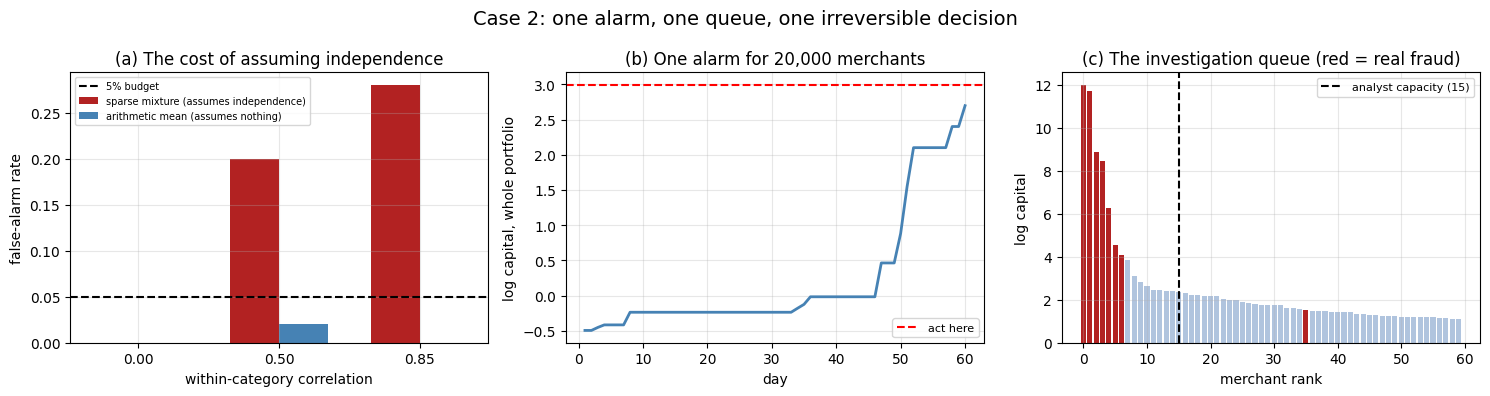

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
x = np.arange(len(trap_rows))
width = 0.35
ax.bar(x - width / 2, [r['sparse'] for r in trap_rows], width,
       color='firebrick', label='sparse mixture (assumes independence)')
ax.bar(x + width / 2, [r['mean'] for r in trap_rows], width,
       color='steelblue', label='arithmetic mean (assumes nothing)')
ax.axhline(ALPHA, color='black', ls='--', label='5% budget')
ax.set_xticks(x); ax.set_xticklabels([f"{r['correlation']:.2f}" for r in trap_rows])
ax.set_xlabel('within-category correlation'); ax.set_ylabel('false-alarm rate')
ax.set_title('(a) The cost of assuming independence')
ax.legend(fontsize=7); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(range(1, DAYS + 1), np.maximum.accumulate(alarm_curve), lw=2, color='steelblue')
ax.axhline(LOG_ACT_AT, color='red', ls='--', label='act here')
if alarm_day:
    ax.axvline(alarm_day, color='firebrick', ls=':', label=f'alarm on day {alarm_day}')
ax.set_xlabel('day'); ax.set_ylabel('log capital, whole portfolio')
ax.set_title('(b) One alarm for 20,000 merchants')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[2]
top = ranking[:60]
colours = ['firebrick' if i in truth else 'lightsteelblue' for i in top]
ax.bar(range(len(top)), np.log(capital[top]), color=colours)
ax.axvline(15, color='black', ls='--', label='analyst capacity (15)')
ax.set_xlabel('merchant rank'); ax.set_ylabel('log capital')
ax.set_title('(c) The investigation queue (red = real fraud)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('Case 2: one alarm, one queue, one irreversible decision', fontsize=14)
plt.tight_layout()
plt.show()

## 2.7 Runbook

1. **Decide the dependence question before anything else.** If merchants share
   categories, geographies, acquirers or card networks, they are correlated, and only
   `ArithmeticMeanMerger` is defensible for the portfolio alarm. Reach for
   `SparseMixtureMerger` only for genuinely independent streams; measure the false-alarm
   rate on clean simulated data before trusting it in either case.
2. **Portfolio alarm** goes to the risk committee daily. One line: capital, and the day
   it crossed.
3. **Investigation queue** is the capital ranking truncated at analyst capacity. No
   threshold. Re-rank daily; it is fine for a merchant to leave the queue, because
   nothing external happened.
4. **Notification** is gated on `adjusted_e_bh` only. If it is not on that list, it does
   not get a letter. Expect this list to be short and to move slowly - that is the
   product, not a defect.
5. **Track the lapse rate** of your raw threshold every month. If you ever see pressure
   to notify off the raw ranking, that number is the argument.
6. Record the standardisation window for each merchant's signal. The whole thing assumes
   a clean merchant looks like noise around zero; if the baseline is stale, everything
   downstream inherits the error.

# Case 3: A Trading Desk Asks Which Strategies Still Work

## 3.1 The business

A systematic desk runs 200 strategies. Every month the investment committee reallocates
capital, and the recurring question is "which of these has stopped working?"

Strategies decay for real reasons: an edge gets crowded, a counterparty changes
behaviour, a venue changes its fee schedule, the regime that generated the edge ends.
Capital sitting in a dead strategy is not merely unproductive - it carries risk that is
no longer compensated.

The committee wants a cut list. The obvious approach is to test each strategy's P&L
against zero and cut the ones that fail.

**That approach cannot work, and it is worth understanding exactly why before building
anything.**

## 3.2 The uncomfortable arithmetic

A Sharpe ratio is a signal-to-noise ratio measured per year. Sharpe 1.0 means the annual
return equals the annual volatility, which sounds impressive and, per trading day, is
almost nothing: dividing by the square root of 252 trading days gives a daily
signal-to-noise of about 0.063.

To distinguish a strategy from one with no edge you need enough evidence to overcome that
ratio. Below is what that requires. The numbers are not a property of this library -
they are a property of having one observation per day.

In [13]:
TRADING_DAYS_PER_YEAR = 252

print("How long to prove a strategy's edge is gone, from daily P&L alone:\n")
print(f"{'true Sharpe now':>17} {'daily signal/noise':>20} {'days needed':>14} {'years':>8}")
for sharpe in (-1.0, -0.5, -0.25, 0.25, 0.5):
    daily_edge = abs(sharpe) / np.sqrt(TRADING_DAYS_PER_YEAR)
    days = LOG_ACT_AT / (daily_edge**2 / 2)
    print(f"{sharpe:>+17.2f} {daily_edge:20.4f} {days:14,.0f} "
          f"{days / TRADING_DAYS_PER_YEAR:8,.1f}")

print()
print("A strategy that has gone from good to actively losing money at Sharpe -0.5 needs")
print("roughly 24 years of daily P&L to prove it. The investment committee meets monthly.")
print()
print("This is not pessimism about the method. Any method faces it, because the")
print("information simply is not in 250 numbers a year. The mistake is not choosing the")
print("wrong test - it is testing the wrong quantity.")

How long to prove a strategy's edge is gone, from daily P&L alone:

  true Sharpe now   daily signal/noise    days needed    years
            -1.00               0.0630          1,510      6.0
            -0.50               0.0315          6,039     24.0
            -0.25               0.0157         24,158     95.9
            +0.25               0.0157         24,158     95.9
            +0.50               0.0315          6,039     24.0

A strategy that has gone from good to actively losing money at Sharpe -0.5 needs
roughly 24 years of daily P&L to prove it. The investment committee meets monthly.

This is not pessimism about the method. Any method faces it, because the
information simply is not in 250 numbers a year. The mistake is not choosing the
wrong test - it is testing the wrong quantity.


## 3.3 Test the mechanism, not the P&L

P&L is one number a day. The *mechanisms* that generate P&L produce thousands of
observations a day, and they degrade before the P&L does.

- **Execution quality.** Every fill has a slippage against the decision price. A desk
  doing 5,000 fills a day gets 5,000 observations a day. When an edge gets crowded,
  slippage widens - often months before it shows up in returns.
- **Fill rate.** What fraction of intended orders actually execute. Thousands of
  attempts daily.
- **Signal decay.** The correlation between the signal and the subsequent return, per
  trade rather than per day.

All three have the same property: **lots of observations, each carrying a little
information**, which is precisely the regime where sequential testing pays off. Below we
monitor slippage against the desk's cost model.

In [14]:
rng = np.random.default_rng(3)

MODEL_SLIPPAGE_BP = 1.20      # what the cost model assumes
ACTUAL_SLIPPAGE_BP = 1.62     # what the market is really charging now
FILL_NOISE_BP = 8.0           # fill-to-fill variability
FILLS_PER_DAY = 5000

slippage_test = SequentialTesting(
    test_type="mean", null_value=MODEL_SLIPPAGE_BP, alternative="greater"
)

fills_seen, detected_at = 0, None
for batch in range(400):
    fills = rng.normal(ACTUAL_SLIPPAGE_BP, FILL_NOISE_BP, 250)
    fills_seen += 250
    if slippage_test.update(fills).reject_null:
        detected_at = fills_seen
        break

print(f"cost model assumes  : {MODEL_SLIPPAGE_BP:.2f} bp per fill")
print(f"reality             : {ACTUAL_SLIPPAGE_BP:.2f} bp per fill "
      f"(+{ACTUAL_SLIPPAGE_BP - MODEL_SLIPPAGE_BP:.2f} bp)")
print(f"fill-to-fill noise  : {FILL_NOISE_BP:.1f} bp")
print()
print(f"proven after        : {detected_at:,} fills "
      f"(~{detected_at / FILLS_PER_DAY:.1f} trading days)")
print()

annual_notional = 40e9
cost_gap = (ACTUAL_SLIPPAGE_BP - MODEL_SLIPPAGE_BP) / 10_000
print(f"On {annual_notional / 1e9:.0f}bn of annual notional that {ACTUAL_SLIPPAGE_BP - MODEL_SLIPPAGE_BP:.2f}bp "
      f"gap is {annual_notional * cost_gap / 1e6:,.1f}m a year of costs")
print("the model is not charging the strategy for.")
print()
print("Four hours, versus twenty-four years. Same desk, same decay, different question.")

cost model assumes  : 1.20 bp per fill
reality             : 1.62 bp per fill (+0.42 bp)
fill-to-fill noise  : 8.0 bp

proven after        : 1,750 fills (~0.3 trading days)

On 40bn of annual notional that 0.42bp gap is 1.7m a year of costs
the model is not charging the strategy for.

Four hours, versus twenty-four years. Same desk, same decay, different question.


## 3.4 The assumption that will bite you: the noise level

The parallel engine takes a `variance` argument - how noisy you claim each observation
is. Everything downstream depends on it, and the failure is asymmetric in a way worth
knowing precisely:

- **Overstate the noise** and the test is slower than it needed to be. Still correct.
- **Understate the noise** and the test is over-confident. **No longer correct.**

Financial data makes it easy to understate: volatility clusters, so a calm estimation
window produces a variance that is far too small for the next stressed period. Below we
measure the damage. Everything tested is null, so every rejection is a false alarm.

In [15]:
print("All strategies are null. Real observation noise has variance 1.0.\n")
print(f"{'assumed variance':>18} {'false-alarm rate':>18} {'verdict':>26}")

for assumed in (0.5, 0.7, 1.0, 1.5, 2.0):
    rates = []
    for replication in range(25):
        rng_r = np.random.default_rng(700 + replication)
        engine_v = ParallelSequentialTest(
            config=ParallelTestConfig(n_tests=2000, alpha=ALPHA, alternative="greater"),
            null_values=0.0,
            variance=assumed,
        )
        for _ in range(60):
            engine_v.step(rng_r.standard_normal(2000))
        rates.append(engine_v.rejected().mean())

    rate = float(np.mean(rates))
    if rate > ALPHA * 1.25:
        verdict = "INVALID - over-confident"
    elif rate > ALPHA:
        verdict = "borderline"
    else:
        verdict = "valid (conservative)"
    print(f"{assumed:18.1f} {rate:18.2%} {verdict:>26}")

print()
print("Understating the noise by half turns a 5% error budget into roughly 14%.")
print("Overstating it costs speed and nothing else.")
print()
print("Practical rule for a desk: estimate the variance on a stressed window, not a calm")
print("one, and round it up. You are buying validity with time, which is the right side")
print("of that trade when the output feeds a capital allocation decision.")

All strategies are null. Real observation noise has variance 1.0.

  assumed variance   false-alarm rate                    verdict


               0.5             14.00%   INVALID - over-confident


               0.7              5.85%                 borderline


               1.0              1.55%       valid (conservative)


               1.5              0.14%       valid (conservative)


               2.0              0.01%       valid (conservative)

Understating the noise by half turns a 5% error budget into roughly 14%.
Overstating it costs speed and nothing else.

Practical rule for a desk: estimate the variance on a stressed window, not a calm
one, and round it up. You are buying validity with time, which is the right side
of that trade when the output feeds a capital allocation decision.


## 3.5 Across the whole book

Now run it for real: 200 strategies, each monitored on execution quality, with two
outputs.

**The book-level alarm** answers "is execution degrading across the desk?" - a question
about infrastructure, venue selection or a market-wide change rather than any one
strategy. Strategies share venues and market factors, so they are correlated, so the
arithmetic mean is the merger (same reasoning as case 2).

**The cut list** names individual strategies and feeds a capital decision, so it uses
the carefree rule (same reasoning as case 2.6). Capital reallocation is not quite
irreversible, but reversing it is expensive and makes the committee look unserious.

In [16]:
N_STRATEGIES = 200
FILLS_PER_STRATEGY_PER_DAY = 40
DAYS = 60

rng = np.random.default_rng(6)

# Reality: an unknown subset has degrading execution, by unknown amounts.
degrading = rng.random(N_STRATEGIES) < 0.12
actual_slippage = np.where(
    degrading,
    np.clip(rng.normal(1.75, 0.25, N_STRATEGIES), MODEL_SLIPPAGE_BP, None),
    MODEL_SLIPPAGE_BP,
)

# Daily average of 40 fills, so the noise on a daily average is (fill noise)^2 / 40.
book = ParallelSequentialTest(
    config=ParallelTestConfig(n_tests=N_STRATEGIES, alpha=ALPHA, alternative="greater"),
    null_values=MODEL_SLIPPAGE_BP,
    variance=FILL_NOISE_BP**2 / FILLS_PER_STRATEGY_PER_DAY,
)
book_merger = ArithmeticMeanMerger(N_STRATEGIES)

book_curve, book_alarm = [], None
for day in range(DAYS):
    daily_average = np.array([
        rng.normal(actual_slippage[i], FILL_NOISE_BP, FILLS_PER_STRATEGY_PER_DAY).mean()
        for i in range(N_STRATEGIES)
    ])
    book.step(daily_average)
    book_curve.append(book_merger.merge(np.exp(book.log_e_processes())).log_merged_e_value)
    if book_alarm is None and max(book_curve) >= LOG_ACT_AT:
        book_alarm = day + 1

cut_list = book.adjusted_e_bh()
named = set(np.flatnonzero(cut_list.rejected).tolist())
really_degrading = set(np.flatnonzero(degrading).tolist())

print(f"strategies monitored       : {N_STRATEGIES}")
print(f"actually degrading         : {degrading.sum()} (revealed now)")
print()
print(f"book-level alarm           : day {book_alarm}")
print(f"  -> 'execution is degrading somewhere on the desk', escalate to the trading")
print(f"     infrastructure team, not to any single portfolio manager")
print()
print(f"cut list (carefree rule)   : {cut_list.n_rejected} strategies")
print(f"  correctly named          : {len(named & really_degrading)}")
print(f"  wrongly named            : {len(named - really_degrading)}")
print(f"  degrading but not caught : {len(really_degrading - named)}")
print()
print("The cut list is deliberately shorter than the truth. Every name on it is one the")
print("committee can defend, and none of them will be walked back next month.")

strategies monitored       : 200
actually degrading         : 22 (revealed now)

book-level alarm           : day 11
  -> 'execution is degrading somewhere on the desk', escalate to the trading
     infrastructure team, not to any single portfolio manager

cut list (carefree rule)   : 4 strategies
  correctly named          : 4
  wrongly named            : 0
  degrading but not caught : 18

The cut list is deliberately shorter than the truth. Every name on it is one the
committee can defend, and none of them will be walked back next month.


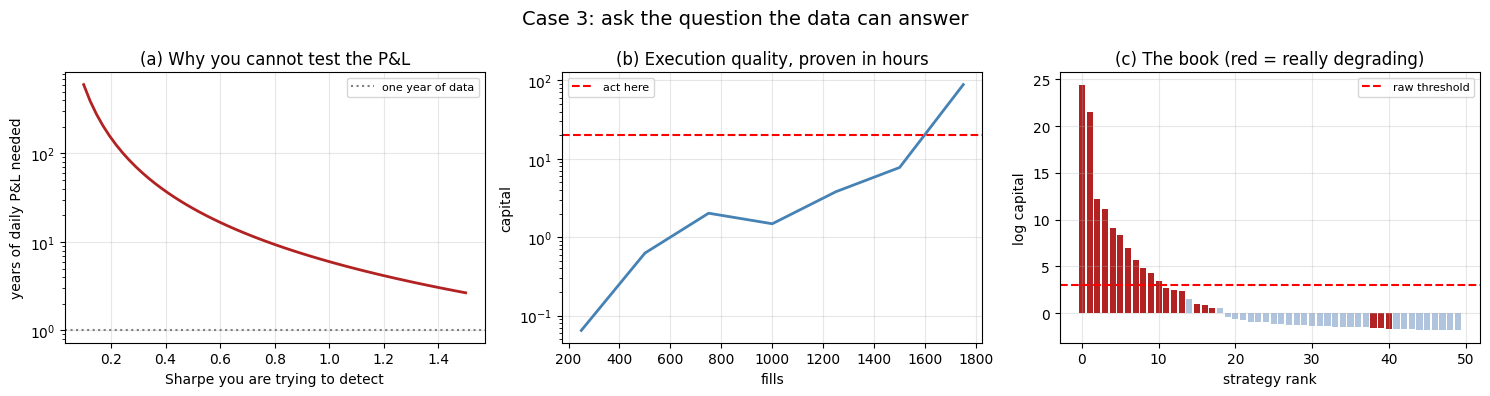

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
sharpes = np.linspace(0.1, 1.5, 60)
years = [LOG_ACT_AT / ((s / np.sqrt(TRADING_DAYS_PER_YEAR))**2 / 2) / TRADING_DAYS_PER_YEAR
         for s in sharpes]
ax.plot(sharpes, years, lw=2, color='firebrick')
ax.axhline(1, color='grey', ls=':', label='one year of data')
ax.set_yscale('log'); ax.set_xlabel('Sharpe you are trying to detect')
ax.set_ylabel('years of daily P&L needed')
ax.set_title('(a) Why you cannot test the P&L')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
history = slippage_test.get_history_df()
ax.plot(history['sample_size'], history['cumulative_e_value'], lw=2, color='steelblue')
ax.axhline(ACT_AT, color='red', ls='--', label='act here')
ax.set_yscale('log'); ax.set_xlabel('fills'); ax.set_ylabel('capital')
ax.set_title('(b) Execution quality, proven in hours')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[2]
strategy_capital = book.log_e_processes()
order = np.argsort(strategy_capital)[::-1][:50]
colours = ['firebrick' if i in really_degrading else 'lightsteelblue' for i in order]
ax.bar(range(len(order)), strategy_capital[order], color=colours)
ax.axhline(LOG_ACT_AT, color='red', ls='--', label='raw threshold')
ax.set_xlabel('strategy rank'); ax.set_ylabel('log capital')
ax.set_title('(c) The book (red = really degrading)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('Case 3: ask the question the data can answer', fontsize=14)
plt.tight_layout()
plt.show()

## 3.6 Runbook

1. **Do not test strategy P&L against zero.** Put the years-required table in front of
   anyone who proposes it. One observation a day cannot resolve a Sharpe difference on
   any timescale the committee operates on.
2. **Monitor mechanisms instead**: slippage per fill, fill rate, signal-return
   correlation per trade. Thousands of observations a day, and they degrade first.
3. **Estimate observation noise on a stressed window and round up.** Understating it is
   the one error that makes the output invalid rather than merely slow.
4. **Book-level alarm** uses `ArithmeticMeanMerger`, because strategies share venues and
   factors. It routes to infrastructure, not to a portfolio manager.
5. **Cut list** uses `adjusted_e_bh`. Short, defensible, and does not reverse.
6. **Report capital, not p-values,** to the committee. "This strategy's execution is 900x
   more consistent with degradation than with the cost model" is a sentence a risk
   officer can act on.

# What the Three Cases Have in Common

Different industries, different data, one set of lessons.

**1. Separate the decision from the estimate.** "Is there a difference?" is valid under
any stopping rule. "How big is it?" is not - stopping early during a transient, whether
that is a novelty effect or a volatility spike, gives an honest measurement of a
temporary state. Case 1 measured the gap at 2.7x. Gate ship decisions on evidence; take
numbers for the financial model from a stable window.

**2. Independence is a claim, and it is usually false.** Guardrail metrics share users.
Merchants share categories. Strategies share venues. Every product-style combining rule
assumes independence, and case 2 measured the cost of assuming it wrongly: a 5% budget
turning into 32%. When in doubt, `ArithmeticMeanMerger`. It is weaker and it is correct.

**3. Decide in advance whether a flag is reversible.** Filling an investigation queue is
reversible and should use the raw ranking. Sending a legal notice is not and must use the
carefree rule. Case 2 found 299 raw alerts of which 290 later evaporated, while the
carefree rule named nobody - that is not a statistical detail, it is whether your
analysts still trust the system in six months.

**4. Test the quantity your data can actually resolve.** Case 3's desk could not answer
its question from P&L in under two decades, and could answer a better version of it in
four hours. When a test seems underpowered, the fix is more often a different measurement
than a bigger sample.

**5. Report capital, not p-values.** "We turned 1 dollar into 340" needs no statistical
training to act on, carries the strength of the evidence rather than just a threshold,
and stays true no matter how many times anyone looked.

**Where to go next:** `toolkit-tour.ipynb` covers every tool used here plus the ones that
did not come up, and states plainly which parts of the library are still under repair.